In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bank-full.csv",sep=";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# age -> müşterinin yaşı
# job -> müşterinin işi
# marital -> müşterinin medeni hali
# education -> müşterinin eğitim seviyesi
# default -> müşterinin kredi borcu var mı?
# balance -> müşterinin banka hesabındaki para
# housing -> müşterinin konut kredisi var mı?
# loan -> müşterinin kişisel kredi borcu var mı?
# contact -> bankanın müşteriye ulaştığı iletişim tipi
# day -> son iletişimin yapıldığı gün
# month -> son iletişimin yapıldığı ay
# duration -> son iletişim zamanı (saniye)
# campaign -> müşteriye yapılan iletişim sayısı
# pdays -> önceki kampanya ile bu müşteri arasındaki iletişim sayısı
#    ( eğer müşteri önceki kampanyada aranmadıysa -1)
# previous -> önceki kampanyalarda bu müşteriye yapılan arama sayısı
# poutcome -> önceki kampanya sonucu
# y -> müşteri mevcut kampanyada banka ürünü kullanmış mı (hedef değişken)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df["job"].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [7]:
df["y"] = df["y"].map({"yes":1,"no":0}).astype(int)

In [8]:
job_target = df.groupby("job")["y"].mean()

In [9]:
job_target

job
admin.           0.122027
blue-collar      0.072750
entrepreneur     0.082717
housemaid        0.087903
management       0.137556
retired          0.227915
self-employed    0.118429
services         0.088830
student          0.286780
technician       0.110570
unemployed       0.155027
unknown          0.118056
Name: y, dtype: float64

In [10]:
df["job_target"] = df["job"].map(job_target)

In [11]:
df = df.drop("job",axis=1)

In [12]:
df.head()

,age,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,job_target
0,58,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,0.137556
1,44,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,0.110570
2,33,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,0.082717
3,47,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,0.072750
4,33,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,0.118056


In [13]:
df["marital"].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [14]:
df = pd.get_dummies(df,columns=["marital"],drop_first=True)

In [15]:
df.tail()

,age,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,job_target,marital_married,marital_single
45206,51,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,1,0.110570,True,False
45207,71,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,1,0.227915,False,False
45208,72,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,1,0.227915,True,False
45209,57,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,0,0.072750,True,False
45210,37,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,0,0.082717,True,False


In [16]:
df["marital_married"] = df["marital_married"].astype(int)
df["marital_single"] = df["marital_single"].astype(int)

In [17]:
df["education"].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [18]:
df = pd.get_dummies(df,columns=["education"],drop_first=False) # drop_first=True yapmamamızın sebebi eğer diğer değişkenler 0 ise bunun unknown olduğunu bilemez

In [19]:
df.head()

,age,default,balance,housing,loan,contact,day,month,duration,campaign,...,previous,poutcome,y,job_target,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown
0,58,no,2143,yes,no,unknown,5,may,261,1,...,0,unknown,0,0.137556,1,0,False,False,True,False
1,44,no,29,yes,no,unknown,5,may,151,1,...,0,unknown,0,0.110570,0,1,False,True,False,False
2,33,no,2,yes,yes,unknown,5,may,76,1,...,0,unknown,0,0.082717,1,0,False,True,False,False
3,47,no,1506,yes,no,unknown,5,may,92,1,...,0,unknown,0,0.072750,1,0,False,False,False,True
4,33,no,1,no,no,unknown,5,may,198,1,...,0,unknown,0,0.118056,0,1,False,False,False,True


In [20]:
df["education_primary"] = df["education_primary"].astype(int)
df["education_secondary"] = df["education_secondary"].astype(int)
df["education_tertiary"] = df["education_tertiary"].astype(int)
df["education_unknown"] = df["education_unknown"].astype(int)


In [21]:
df["default"] = df["default"].map({"yes":1,"no":0}).astype(int)

In [22]:
df["housing"] = df["housing"].map({"yes":1,"no":0}).astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  45211 non-null  int64  
 1   default              45211 non-null  int64  
 2   balance              45211 non-null  int64  
 3   housing              45211 non-null  int64  
 4   loan                 45211 non-null  object 
 5   contact              45211 non-null  object 
 6   day                  45211 non-null  int64  
 7   month                45211 non-null  object 
 8   duration             45211 non-null  int64  
 9   campaign             45211 non-null  int64  
 10  pdays                45211 non-null  int64  
 11  previous             45211 non-null  int64  
 12  poutcome             45211 non-null  object 
 13  y                    45211 non-null  int64  
 14  job_target           45211 non-null  float64
 15  marital_married      45211 non-null 

In [24]:
df["loan"].value_counts()

loan
no     37967
yes     7244
Name: count, dtype: int64

In [25]:
df["loan"] = df["loan"].map({"yes":1,"no":0}).astype(int)

In [26]:
df["contact"].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [27]:
df = pd.get_dummies(df,columns=["contact"], drop_first=True)

In [28]:
df.head()

,age,default,balance,housing,loan,day,month,duration,campaign,pdays,...,y,job_target,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown
0,58,0,2143,1,0,5,may,261,1,-1,...,0,0.137556,1,0,0,0,1,0,False,True
1,44,0,29,1,0,5,may,151,1,-1,...,0,0.110570,0,1,0,1,0,0,False,True
2,33,0,2,1,1,5,may,76,1,-1,...,0,0.082717,1,0,0,1,0,0,False,True
3,47,0,1506,1,0,5,may,92,1,-1,...,0,0.072750,1,0,0,0,0,1,False,True
4,33,0,1,0,0,5,may,198,1,-1,...,0,0.118056,0,1,0,0,0,1,False,True


In [29]:
df["contact_telephone"] = df["contact_telephone"].astype(int)
df["contact_unknown"] = df["contact_unknown"].astype(int)

In [30]:
df["month"].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

In [31]:
month_target = df.groupby("month")["y"].mean()

In [32]:
month_target

month
apr    0.196794
aug    0.110133
dec    0.467290
feb    0.166478
jan    0.101212
jul    0.090935
jun    0.102228
mar    0.519916
may    0.067195
nov    0.101511
oct    0.437669
sep    0.464594
Name: y, dtype: float64

In [33]:
df["month_target"] = df["month"].map(month_target)

In [34]:
df = df.drop("month",axis=1)

In [35]:
df.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,job_target,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_target
0,58,0,2143,1,0,5,261,1,-1,0,...,0.137556,1,0,0,0,1,0,0,1,0.067195
1,44,0,29,1,0,5,151,1,-1,0,...,0.110570,0,1,0,1,0,0,0,1,0.067195
2,33,0,2,1,1,5,76,1,-1,0,...,0.082717,1,0,0,1,0,0,0,1,0.067195
3,47,0,1506,1,0,5,92,1,-1,0,...,0.072750,1,0,0,0,0,1,0,1,0.067195
4,33,0,1,0,0,5,198,1,-1,0,...,0.118056,0,1,0,0,0,1,0,1,0.067195


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  45211 non-null  int64  
 1   default              45211 non-null  int64  
 2   balance              45211 non-null  int64  
 3   housing              45211 non-null  int64  
 4   loan                 45211 non-null  int64  
 5   day                  45211 non-null  int64  
 6   duration             45211 non-null  int64  
 7   campaign             45211 non-null  int64  
 8   pdays                45211 non-null  int64  
 9   previous             45211 non-null  int64  
 10  poutcome             45211 non-null  object 
 11  y                    45211 non-null  int64  
 12  job_target           45211 non-null  float64
 13  marital_married      45211 non-null  int64  
 14  marital_single       45211 non-null  int64  
 15  education_primary    45211 non-null 

In [37]:
df["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [38]:
df = pd.get_dummies(df,columns=["poutcome"],drop_first=False)

In [39]:
df.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_target,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,261,1,-1,0,...,0,1,0,0,1,0.067195,False,False,False,True
1,44,0,29,1,0,5,151,1,-1,0,...,1,0,0,0,1,0.067195,False,False,False,True
2,33,0,2,1,1,5,76,1,-1,0,...,1,0,0,0,1,0.067195,False,False,False,True
3,47,0,1506,1,0,5,92,1,-1,0,...,0,0,1,0,1,0.067195,False,False,False,True
4,33,0,1,0,0,5,198,1,-1,0,...,0,0,1,0,1,0.067195,False,False,False,True


In [40]:
df["poutcome_failure"] = df["poutcome_failure"].astype(int)
df["poutcome_other"] = df["poutcome_other"].astype(int)
df["poutcome_success"] = df["poutcome_success"].astype(int)
df["poutcome_unknown"] = df["poutcome_unknown"].astype(int)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  45211 non-null  int64  
 1   default              45211 non-null  int64  
 2   balance              45211 non-null  int64  
 3   housing              45211 non-null  int64  
 4   loan                 45211 non-null  int64  
 5   day                  45211 non-null  int64  
 6   duration             45211 non-null  int64  
 7   campaign             45211 non-null  int64  
 8   pdays                45211 non-null  int64  
 9   previous             45211 non-null  int64  
 10  y                    45211 non-null  int64  
 11  job_target           45211 non-null  float64
 12  marital_married      45211 non-null  int64  
 13  marital_single       45211 non-null  int64  
 14  education_primary    45211 non-null  int64  
 15  education_secondary  45211 non-null 

In [42]:
df.describe()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_target,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,...,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,0.018027,1362.272058,0.555838,0.160226,15.806419,258.163080,2.763841,40.197828,0.580323,...,0.513194,0.294198,0.041074,0.064276,0.287983,0.116985,0.108403,0.040698,0.033421,0.817478
std,10.618762,0.133049,3044.765829,0.496878,0.366820,8.322476,257.527812,3.098021,100.128746,2.303441,...,0.499831,0.455687,0.198464,0.245247,0.452828,0.083642,0.310892,0.197592,0.179735,0.386278
min,18.000000,0.000000,-8019.000000,0.000000,0.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.067195,0.000000,0.000000,0.000000,0.000000
25%,33.000000,0.000000,72.000000,0.000000,0.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.067195,0.000000,0.000000,0.000000,1.000000
50%,39.000000,0.000000,448.000000,1.000000,0.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.101511,0.000000,0.000000,0.000000,1.000000
75%,48.000000,0.000000,1428.000000,1.000000,0.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,0.110133,0.000000,0.000000,0.000000,1.000000
max,95.000000,1.000000,102127.000000,1.000000,1.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.519916,1.000000,1.000000,1.000000,1.000000


In [43]:
df.corr()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_target,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
age,1.000000,-0.017879,0.097783,-0.185513,-0.015655,-0.009120,-0.004648,0.004760,-0.023758,0.001288,...,-0.093979,-0.081629,0.069665,0.170349,-0.020132,0.081646,-0.004927,-0.022967,0.035526,-0.000816
default,-0.017879,1.000000,-0.066745,-0.006025,0.077234,0.009424,-0.010021,0.016822,-0.029979,-0.018329,...,0.013220,-0.015239,-0.001236,-0.017208,0.019933,-0.036926,-0.026389,-0.014445,-0.023344,0.039490
balance,0.097783,-0.066745,1.000000,-0.068768,-0.084350,0.004503,0.021560,-0.014578,0.003435,0.016674,...,-0.069937,0.084001,0.011181,0.037999,-0.037331,0.069998,0.011857,0.008466,0.035240,-0.030271
housing,-0.185513,-0.006025,-0.068768,1.000000,0.041323,-0.027982,0.005075,-0.023599,0.124178,0.037076,...,0.101659,-0.099175,-0.047595,-0.080822,0.208409,-0.208459,0.106795,0.039710,-0.091360,-0.063755
loan,-0.015655,0.077234,-0.084350,0.041323,1.000000,0.011370,-0.012412,0.009980,-0.022754,-0.011043,...,0.070625,-0.045940,-0.049992,-0.013183,-0.007211,-0.067294,-0.002186,-0.009099,-0.053713,0.031406
day,-0.009120,0.009424,0.004503,-0.027982,0.011370,1.000000,-0.030206,0.162490,-0.093044,-0.051710,...,-0.005831,0.021730,0.000114,0.023652,-0.034103,-0.064633,-0.068700,-0.032952,-0.030321,0.086256
duration,-0.004648,-0.010021,0.021560,0.005075,-0.012412,-0.030206,1.000000,-0.084570,-0.001565,0.001203,...,0.002084,0.000891,-0.000682,-0.023201,-0.014379,0.024088,-0.018925,-0.001958,0.042389,-0.003491
campaign,0.004760,0.016822,-0.014578,-0.023599,0.009980,0.162490,-0.084570,1.000000,-0.088628,-0.032855,...,-0.020893,0.012866,0.005704,0.053895,0.004853,-0.068577,-0.088131,-0.020107,-0.057486,0.107965
pdays,-0.023758,-0.029979,0.003435,0.124178,-0.022754,-0.093044,-0.001565,-0.088628,1.000000,0.454820,...,0.022105,-0.007568,-0.006907,0.016006,-0.247068,0.141325,0.701052,0.389791,0.228539,-0.869962
previous,0.001288,-0.018329,0.016674,0.037076,-0.011043,-0.051710,0.001203,-0.032855,0.454820,1.000000,...,-0.005603,0.022888,-0.008257,0.028097,-0.154162,0.112622,0.350627,0.306615,0.201424,-0.532763


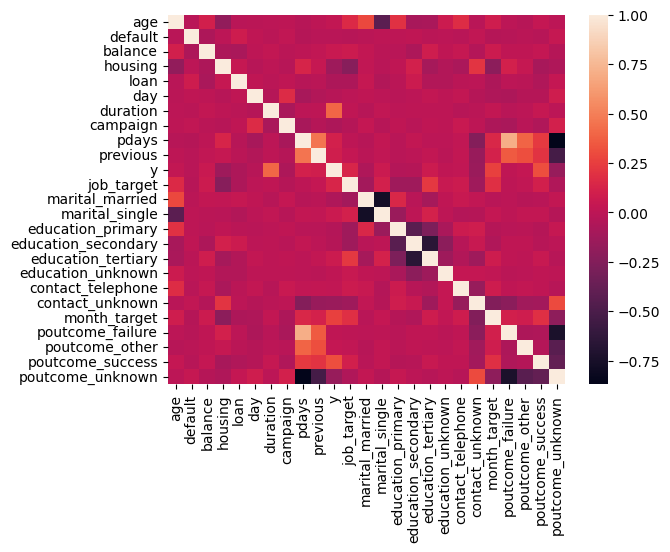

In [44]:
sns.heatmap(df.corr())
plt.show()

In [45]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                colname = corr.columns[i]
                columns_to_drop.add(colname)
    return columns_to_drop

In [46]:
correlation_for_dropping(df,threshold=0.8)

{'poutcome_unknown'}

In [47]:
def remove_outliers_from_column(df,target_col,threshold=1.5):
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    return df[(df[target_col] >= lower_bound) & (df[target_col] <=upper_bound)]

In [48]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"default")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (44396, 25)


In [49]:
def fin_outliers_iqr(df,threshold=1.5):
    outlier_summary = {}

    columns = df.columns
   
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }

    return pd.DataFrame(outlier_summary)

In [50]:
fin_outliers_iqr(df,threshold=1.5)

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_target,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
outlier_count,487.000000,815.000000,4729.000000,0.0,7244.000000,0.0,3235.000000,3064.000000,8257.000000,8257.000000,...,0.0,0.0,1857.000000,2906.000000,0.0,4940.000000,4901.000000,1840.000000,1511.000000,8252.000000
outlier_percentage,1.077171,1.802659,10.459844,0.0,16.022649,0.0,7.155338,6.777112,18.263255,18.263255,...,0.0,0.0,4.107407,6.427639,0.0,10.926544,10.840282,4.069806,3.342107,18.252195
lower_bound,10.500000,0.000000,-1962.000000,-1.5,0.000000,-11.5,-221.000000,-2.000000,-1.000000,0.000000,...,-1.5,-1.5,0.000000,0.000000,-1.5,0.002787,0.000000,0.000000,0.000000,1.000000
upper_bound,70.500000,0.000000,3462.000000,2.5,0.000000,40.5,643.000000,6.000000,-1.000000,0.000000,...,2.5,2.5,0.000000,0.000000,2.5,0.174540,0.000000,0.000000,0.000000,1.000000


In [51]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"balance")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (40482, 25)


In [52]:
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["balance"] = df["balance"].clip(lower=lower_bound,upper=upper_bound)

In [53]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"balance")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [54]:
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["balance"] = df["balance"].clip(lower=lower_bound,upper=upper_bound)

In [55]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"balance")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [56]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"default")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (44396, 25)


In [57]:
Q1 = df["default"].quantile(0.25)
Q3 = df["default"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["default"] = df["default"].clip(lower=lower_bound,upper=upper_bound)

In [58]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"default")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [59]:
Q1 = df["loan"].quantile(0.25)
Q3 = df["loan"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["loan"] = df["loan"].clip(lower=lower_bound,upper=upper_bound)

In [60]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"loan")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [61]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"duration")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (41976, 25)


In [62]:
Q1 = df["duration"].quantile(0.25)
Q3 = df["duration"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["duration"] = df["duration"].clip(lower=lower_bound,upper=upper_bound)

In [63]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"duration")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [64]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"campaign")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (42147, 25)


In [65]:
Q1 = df["campaign"].quantile(0.25)
Q3 = df["campaign"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["campaign"] = df["campaign"].clip(lower=lower_bound,upper=upper_bound)

In [66]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"campaign")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [67]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"pdays")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (36954, 25)


In [68]:
Q1 = df["pdays"].quantile(0.25)
Q3 = df["pdays"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["pdays"] = df["pdays"].clip(lower=lower_bound,upper=upper_bound)

In [69]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"pdays")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [70]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"previous")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (36954, 25)


In [71]:
Q1 = df["previous"].quantile(0.25)
Q3 = df["previous"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["previous"] = df["previous"].clip(lower=lower_bound,upper=upper_bound)

In [72]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"previous")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (45211, 25)
Only target column cleaning shape:  (45211, 25)


In [73]:
X = df.drop("y",axis=1)
y = df["y"]

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

In [76]:
from imblearn.over_sampling import SMOTE

In [77]:
smote = SMOTE(random_state=42)

In [78]:
X_train, y_train = smote.fit_resample(X_train,y_train)

In [79]:
from sklearn.preprocessing import StandardScaler

In [80]:
scaler = StandardScaler()

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [82]:
scaler_models = {
    "Logistic Regression" : LogisticRegression(),
    "KNeighbors Classifier" : KNeighborsClassifier(),
    "SVC" : SVC()
}

In [83]:
models = {
    "Decision Tree Classifier" : DecisionTreeClassifier(),
    "Random Forest Classifier" : RandomForestClassifier(),
    "Gradient Boosting Classifier" : GradientBoostingClassifier(),
    "XGB Classifier" : XGBClassifier(),
    "LGB Classifier" : LGBMClassifier()
}

In [84]:
import warnings
warnings.filterwarnings("ignore")

In [85]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [87]:
def training_all_models(X_train, X_test, y_train, y_test, models):
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(name)
        print("Accuracy score: ",accuracy_score(y_test, y_pred))
        print("Classification Report: ",classification_report(y_test, y_pred))
        print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred))
        print("------------------------------------------")


In [88]:
training_all_models(X_train_scaled,X_test_scaled,y_train,y_test,scaler_models)

Logistic Regression
Accuracy score:  0.8893394278973754
Classification Report:                precision    recall  f1-score   support

           0       0.94      0.94      0.94     12032
           1       0.51      0.53      0.52      1532

    accuracy                           0.89     13564
   macro avg       0.72      0.73      0.73     13564
weighted avg       0.89      0.89      0.89     13564

Confusion Matrix:
  [[11256   776]
 [  725   807]]
------------------------------------------
KNeighbors Classifier
Accuracy score:  0.8805662046593925
Classification Report:                precision    recall  f1-score   support

           0       0.93      0.93      0.93     12032
           1       0.47      0.46      0.46      1532

    accuracy                           0.88     13564
   macro avg       0.70      0.70      0.70     13564
weighted avg       0.88      0.88      0.88     13564

Confusion Matrix:
  [[11240   792]
 [  828   704]]
---------------------------------------

In [89]:
training_all_models(X_train,X_test,y_train,y_test,models)

Decision Tree Classifier
Accuracy score:  0.8650103214391035
Classification Report:                precision    recall  f1-score   support

           0       0.93      0.91      0.92     12032
           1       0.42      0.50      0.45      1532

    accuracy                           0.87     13564
   macro avg       0.68      0.71      0.69     13564
weighted avg       0.88      0.87      0.87     13564

Confusion Matrix:
  [[10969  1063]
 [  768   764]]
------------------------------------------
Random Forest Classifier
Accuracy score:  0.8977440283102329
Classification Report:                precision    recall  f1-score   support

           0       0.94      0.95      0.94     12032
           1       0.55      0.48      0.52      1532

    accuracy                           0.90     13564
   macro avg       0.74      0.72      0.73     13564
weighted avg       0.89      0.90      0.89     13564

Confusion Matrix:
  [[11437   595]
 [  792   740]]
-------------------------------

In [90]:
parameters = {
    "loss" : ["log_loss","exponential"],
    "learning_rate" : [0.01,0.1,0.05],
    "n_estimators" : [100,150,50,180,200],
    "max_depth" : [3,4,5],
    "subsample" : [0.8,1]
}

In [91]:
from sklearn.model_selection import RandomizedSearchCV

In [92]:
random = RandomizedSearchCV(estimator=GradientBoostingClassifier(),param_distributions=parameters,cv=5,n_jobs=-1)

In [93]:
random.fit(X_train,y_train)

,estimator,GradientBoostingClassifier()
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'loss': ['log_loss', 'exponential'], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [94]:
y_pred = random.predict(X_test)

In [95]:
print("Accuracy score: ",accuracy_score(y_test, y_pred))
print("Classification Report: ",classification_report(y_test, y_pred))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred))

Accuracy score:  0.8978914774402831
Classification Report:                precision    recall  f1-score   support

           0       0.94      0.94      0.94     12032
           1       0.55      0.56      0.56      1532

    accuracy                           0.90     13564
   macro avg       0.75      0.75      0.75     13564
weighted avg       0.90      0.90      0.90     13564

Confusion Matrix:
  [[11315   717]
 [  668   864]]


In [96]:
random.best_params_

{'subsample': 0.8,
 'n_estimators': 150,
 'max_depth': 5,
 'loss': 'exponential',
 'learning_rate': 0.05}

In [97]:
model_gradient = GradientBoostingClassifier(subsample=1.0,n_estimators=100,max_depth=3,loss="log_loss",learning_rate=0.1)

In [98]:
model_gradient.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [99]:
y_pred_gradient = model_gradient.predict(X_test)

In [100]:
print("Accuracy score: ",accuracy_score(y_test, y_pred_gradient))
print("Classification Report: ",classification_report(y_test, y_pred_gradient))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred_gradient))

Accuracy score:  0.8925833087584784
Classification Report:                precision    recall  f1-score   support

           0       0.95      0.93      0.94     12032
           1       0.52      0.58      0.55      1532

    accuracy                           0.89     13564
   macro avg       0.73      0.76      0.74     13564
weighted avg       0.90      0.89      0.90     13564

Confusion Matrix:
  [[11213   819]
 [  638   894]]


In [101]:
param_lgb = {
    "n_estimators" : [100,200,300,400,500,1000],
    "max_depth" : [3,5,7,-1],
    "learning_rate" : [0.01,0.05,0.1,0.3],
    "num_leaves" : [7,15,127,255],
    "min_child_samples" : [10,20,30],
    "subsample" : [0.6,0.8,1.0],
    "colsample_bytree" : [0.6,0.8,1.0]
}

In [102]:
random_lgb = RandomizedSearchCV(estimator=LGBMClassifier(),param_distributions=param_lgb,cv=5,n_jobs=-1)

In [103]:
random_lgb.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 27890, number of negative: 27890
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1157
[LightGBM] [Info] Number of data points in the train set: 55780, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,estimator,LGBMClassifier()
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [104]:
y_pred_lgb = random_lgb.predict(X_test)

In [105]:
print("Accuracy score: ",accuracy_score(y_test, y_pred_lgb))
print("Classification Report: ",classification_report(y_test, y_pred_lgb))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred_lgb))

Accuracy score:  0.9021675022117369
Classification Report:                precision    recall  f1-score   support

           0       0.93      0.96      0.95     12032
           1       0.58      0.48      0.52      1532

    accuracy                           0.90     13564
   macro avg       0.76      0.72      0.73     13564
weighted avg       0.89      0.90      0.90     13564

Confusion Matrix:
  [[11508   524]
 [  803   729]]


In [106]:
model_lgb = LGBMClassifier(n_estimators=600,learning_rate=0.02,max_depth=7,num_leaves=35,subsample=1.0,colsample_bytree=0.8,class_weight='balanced',random_state=42)

In [107]:
model_lgb.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 27890, number of negative: 27890
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1157
[LightGBM] [Info] Number of data points in the train set: 55780, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,35
,max_depth,7
,learning_rate,0.02
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [108]:
y_pred = model_lgb.predict(X_test)

In [109]:
print("Accuracy score: ",accuracy_score(y_test, y_pred))
print("Classification Report: ",classification_report(y_test, y_pred))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred))

Accuracy score:  0.9019463285166618
Classification Report:                precision    recall  f1-score   support

           0       0.94      0.95      0.95     12032
           1       0.57      0.52      0.55      1532

    accuracy                           0.90     13564
   macro avg       0.76      0.74      0.75     13564
weighted avg       0.90      0.90      0.90     13564

Confusion Matrix:
  [[11436   596]
 [  734   798]]


In [110]:
model_gradient = GradientBoostingClassifier( n_estimators=600, learning_rate=0.02,max_depth=6,min_samples_split=50, min_samples_leaf=20,subsample=0.8,max_features='sqrt', random_state=42)

In [111]:
model_gradient.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.02
,n_estimators,600
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,50
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


In [112]:
y_pred_gradient = model_gradient.predict(X_test)

In [113]:
print("Accuracy score: ",accuracy_score(y_test, y_pred))
print("Classification Report: ",classification_report(y_test, y_pred))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred))

Accuracy score:  0.9019463285166618
Classification Report:                precision    recall  f1-score   support

           0       0.94      0.95      0.95     12032
           1       0.57      0.52      0.55      1532

    accuracy                           0.90     13564
   macro avg       0.76      0.74      0.75     13564
weighted avg       0.90      0.90      0.90     13564

Confusion Matrix:
  [[11436   596]
 [  734   798]]


In [114]:
y_proba = model_gradient.predict_proba(X_test)[:,1]

In [115]:
y_pred = (y_proba>0.38).astype(int)

In [116]:
from sklearn.metrics import f1_score

In [117]:
print("f1 Score: ",f1_score(y_test,y_pred))

f1 Score:  0.5874086565486228


In [118]:
y_proba_lgb = model_lgb.predict_proba(X_test)[:,1]

In [119]:
y_pred_lgb = (y_proba_lgb>0.38).astype(int)

In [120]:
print("f1 Score: ",f1_score(y_test,y_pred_lgb))

f1 Score:  0.5932545402133179


In [121]:
y_proba = model_lgb.predict_proba(X_test)[:,1]
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.3,0.5,0.01):
    y_pred = (y_proba > thresh).astype(int)
    f1 = f1_score(y_test,y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
print("Best f1: ",best_f1)
print("Best threshold: ",best_thresh)

Best f1:  0.6060921634990888
Best threshold:  0.3


In [122]:
y_pred_best = (y_proba > best_thresh).astype(int)

In [123]:
print("Accuracy score: ",accuracy_score(y_test, y_pred_best))
print("Classification Report: ",classification_report(y_test, y_pred_best))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred_best))

Accuracy score:  0.8884547331170746
Classification Report:                precision    recall  f1-score   support

           0       0.97      0.90      0.94     12032
           1       0.50      0.76      0.61      1532

    accuracy                           0.89     13564
   macro avg       0.74      0.83      0.77     13564
weighted avg       0.91      0.89      0.90     13564

Confusion Matrix:
  [[10887  1145]
 [  368  1164]]


In [124]:
y_proba = model_gradient.predict_proba(X_test)[:,1]
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.3,0.5,0.01):
    y_pred = (y_proba > thresh).astype(int)
    f1 = f1_score(y_test,y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
print("Best f1: ",best_f1)
print("Best threshold: ",best_thresh)

Best f1:  0.591809058855438
Best threshold:  0.35000000000000003


In [125]:
y_pred_best_gradient = (y_proba > best_thresh).astype(int)

In [126]:
print("Accuracy score: ",accuracy_score(y_test, y_pred_best_gradient))
print("Classification Report: ",classification_report(y_test, y_pred_best_gradient))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred_best_gradient))

Accuracy score:  0.8890445296372751
Classification Report:                precision    recall  f1-score   support

           0       0.96      0.91      0.94     12032
           1       0.51      0.71      0.59      1532

    accuracy                           0.89     13564
   macro avg       0.73      0.81      0.76     13564
weighted avg       0.91      0.89      0.90     13564

Confusion Matrix:
  [[10968  1064]
 [  441  1091]]


In [127]:
# lightgbm ile oluşan sonuçlar 

In [128]:
print("Accuracy score: ",accuracy_score(y_test, y_pred_best))
print("Classification Report: ",classification_report(y_test, y_pred_best))
print("Confusion Matrix:\n ",confusion_matrix(y_test, y_pred_best))

Accuracy score:  0.8884547331170746
Classification Report:                precision    recall  f1-score   support

           0       0.97      0.90      0.94     12032
           1       0.50      0.76      0.61      1532

    accuracy                           0.89     13564
   macro avg       0.74      0.83      0.77     13564
weighted avg       0.91      0.89      0.90     13564

Confusion Matrix:
  [[10887  1145]
 [  368  1164]]
